Prédiction : [1]


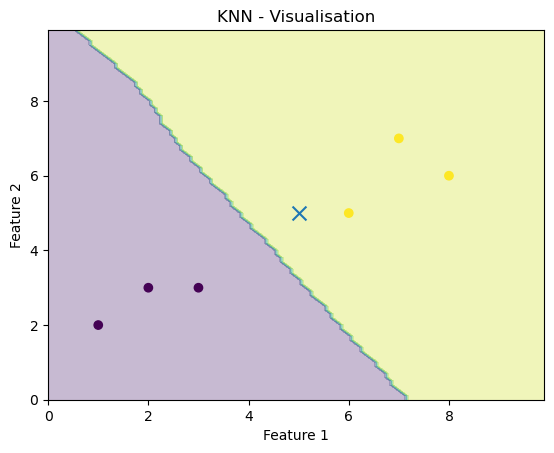

In [3]:
import numpy as np                          # bibliothèque pour calculs numériques (tableaux, matrices)
import matplotlib.pyplot as plt             # bibliothèque pour visualisation graphique
from collections import Counter             # pour compter les votes des voisins

# ==============================
# 1. Distance euclidienne
# ==============================
def distance_euclidienne(x1, x2):
    # calcul de la distance entre deux points dans l'espace
    return np.sqrt(np.sum((x1 - x2) ** 2))   # formule de distance euclidienne


# ==============================
# 2. Classe KNN
# ==============================
class KNN:
    
    def __init__(self, k=3):
        # initialisation du nombre de voisins
        self.k = k
    
    def fit(self, X, y):
        # stockage des données d'entraînement
        self.X_train = X     # features (entrées)
        self.y_train = y     # labels (classes)
    
    def predict(self, X):
        # prédire pour plusieurs points
        return [self._predict(x) for x in X]   # boucle sur chaque point
    
    def _predict(self, x):
        # prédire pour un seul point
        
        # calculer la distance entre x et tous les points d'entraînement
        distances = [distance_euclidienne(x, x_train) for x_train in self.X_train]
        
        # récupérer les indices des k plus petites distances
        k_indices = np.argsort(distances)[:self.k]
        
        # récupérer les labels des k voisins
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        
        # compter les occurrences de chaque classe
        most_common = Counter(k_nearest_labels).most_common(1)
        
        # retourner la classe majoritaire
        return most_common[0][0]


# ==============================
# 3. Dataset (données d'entraînement)
# ==============================
X = np.array([
    [1, 2],   # point classe 0
    [2, 3],   # point classe 0
    [3, 3],   # point classe 0
    [6, 5],   # point classe 1
    [7, 7],   # point classe 1
    [8, 6]    # point classe 1
])

y = np.array([0, 0, 0, 1, 1, 1])  # labels correspondants


# ==============================
# 4. Création et entraînement du modèle
# ==============================
model = KNN(k=3)        # créer le modèle avec 3 voisins
model.fit(X, y)         # entraîner (juste stocker les données)

# ==============================
# 5. Test du modèle
# ==============================
X_test = np.array([[5, 5]])          # nouveau point à prédire
prediction = model.predict(X_test)   # prédiction

print("Prédiction :", prediction)    # affichage du résultat


# ==============================
# 6. VISUALISATION
# ==============================

# création d'une grille de points pour afficher les zones de décision
x_min, x_max = 0, 10                 # bornes axe x
y_min, y_max = 0, 10                 # bornes axe y

# génération de tous les points du plan
xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.1),    # axe x
    np.arange(y_min, y_max, 0.1)     # axe y
)

# transformation de la grille en liste de points
grid_points = np.c_[xx.ravel(), yy.ravel()]

# prédiction pour chaque point de la grille
Z = model.predict(grid_points)

# remise en forme pour affichage 2D
Z = np.array(Z).reshape(xx.shape)

# ==============================
# 7. Affichage graphique
# ==============================

# afficher les régions de décision (fond coloré)
plt.contourf(xx, yy, Z, alpha=0.3)

# afficher les points d'entraînement
plt.scatter(X[:, 0], X[:, 1], c=y)

# afficher le point à tester (croix)
plt.scatter(X_test[:, 0], X_test[:, 1], marker='x', s=100)

# titres et labels
plt.title("KNN - Visualisation")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

# afficher le graphique
plt.show()